# Week 6 · Day 2 — Lab: Polynomial Regression & Overfitting

Practice fitting **curves** with polynomial regression, and diagnosing **underfitting vs overfitting** yourself.

**Scenario:** temperature vs ice-cream sales — sales rise as it gets warmer, peak, then fall when it's too hot. A curve, not a line.

**How to work:** fill each `...` / `# TODO`. When done: Restart & Run All, push as `week-06/day2-lab.ipynb`.

Setup — run first.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# generate the curved dataset
rng = np.random.default_rng(3)
x = np.linspace(10, 40, 25)                     # temperature (°C)
y = -200 + 40*x - 0.7*x**2 + rng.normal(0, 25, 25)   # sales (with noise)
print("data ready:", len(x), "days")

data ready: 25 days


## Part 1 — See the curve, and watch a line fail

**1.1** Scatter-plot the data (temperature on x, sales on y). Add labels and a title.

In [ ]:
# TODO 1.1
plt.scatter(...)
plt.xlabel(...); plt.ylabel(...); plt.title(...)
plt.grid(True, alpha=0.3); plt.show() 

TypeError: scatter() missing 1 required positional argument: 'y'

**1.2** Fit a plain straight line (`LinearRegression` on `x` alone) and plot it over the data. Does a straight line capture the rise-and-fall shape?

ValueError: x and y must have same first dimension, but have shapes (25,) and (1,)

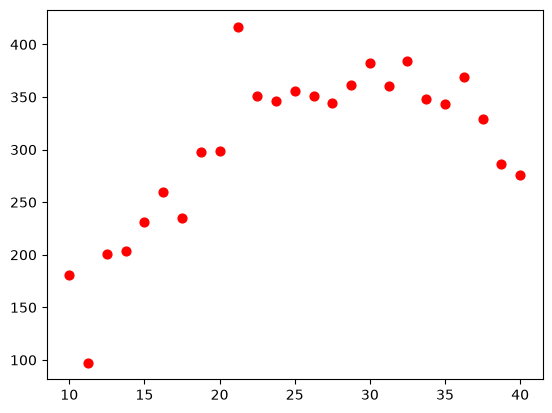

In [7]:
# TODO 1.2
X = x.reshape(-1, 1)
line = ...
plt.scatter(x, y, color="red", s=40, zorder=3, label="data")
plt.plot(x, ..., color="blue", linewidth=2, label="line")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()
# ANSWER: does the line fit well? ...

## Part 2 — Fit a curve by adding features

**2.1** Build polynomial features **by hand**: create `x²` and stack `[x, x²]` into a matrix `X_poly`. Print its shape.

In [ ]:
# TODO 2.1
x2 = ...
X_poly = np.column_stack([x, x2])
print("shape:", X_poly.shape)

**2.2** Fit `LinearRegression` on `X_poly` and plot the resulting curve. (Use a dense `x_smooth` for a smooth line — build its powers the same way.)

In [8]:
# TODO 2.2
curve = LinearRegression().fit(X_poly, y)
x_smooth = np.linspace(10, 40, 200)
X_smooth = np.column_stack([x_smooth, x_smooth**2])
plt.scatter(x, y, color="red", s=40, zorder=3, label="data")
plt.plot(x_smooth, ..., color="green", linewidth=2, label="curve")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

NameError: name 'X_poly' is not defined

**2.3** In one line: which algorithm fit this curve, and what did we change to make it bend?

**ANSWER:** ...

**2.4** Use scikit-learn's `PolynomialFeatures` (degree 2) to build the same features automatically. Print the feature names it creates.

In [ ]:
# TODO 2.4
poly = PolynomialFeatures(degree=2, include_bias=False)
X_auto = ...
print(poly.get_feature_names_out())

## Part 3 — Underfitting vs overfitting

**3.1** Split the data into train (70%) and test (30%), `random_state=3`.

In [ ]:
# TODO 3.1
x_train, x_test, y_train, y_test = ...
print("train:", len(x_train), " test:", len(x_test))

**3.2** Complete this helper that fits a polynomial of a given degree and returns train & test R².

In [ ]:
# TODO 3.2
def fit_poly(degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr = poly.fit_transform(x_train.reshape(-1, 1))
    X_te = poly.transform(x_test.reshape(-1, 1))
    model = LinearRegression().fit(X_tr, y_train)
    r2_tr = ...
    r2_te = ...
    return model, poly, r2_tr, r2_te

**3.3** Fit degrees **1, 3, and 12**. Print each one's train and test R². Which underfits, which is best, which overfits?

In [ ]:
# TODO 3.3
for degree in [1, 3, 12]:
    _, _, r2_tr, r2_te = fit_poly(degree)
    print(f"degree {degree:2d}: train R²={r2_tr:.3f}  test R²={r2_te:.3f}")
# UNDERFIT: degree ...   BEST: degree ...   OVERFIT: degree ...

**3.4** Plot all three fits side by side (degree 1, 3, 12) so you can *see* under/good/over-fitting. Loop over the degrees.

In [ ]:
# TODO 3.4
x_smooth = np.linspace(10, 40, 200)
plt.figure(figsize=(13, 4))
for i, degree in enumerate([1, 3, 12], 1):
    model, poly, r2_tr, r2_te = fit_poly(degree)
    plt.subplot(1, 3, i)
    plt.scatter(x_train, y_train, color="red", s=25, label="train")
    plt.scatter(x_test, y_test, color="orange", s=35, marker="s", label="test")
    plt.plot(x_smooth, model.predict(poly.transform(x_smooth.reshape(-1,1))), color="blue", lw=2)
    plt.ylim(y.min()-60, y.max()+60)
    plt.title(f"degree {degree}, test R²={r2_te:.2f}")
    plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**3.5** The degree-12 model scores well on **training** data but worse on **test** data. Explain in two sentences what that gap means and why it's bad.

**ANSWER:** ...

## Part 4 — Why regression won't do for categories

**4.1** Here's a yes/no problem: does a person exercise regularly, based on their age? The answer is a **category** (0 = no, 1 = yes). Fit a regression line to it and plot. Why is the line a poor fit for this kind of problem?

In [ ]:
age = np.array([18,22,25,30,33,38,42,47,50,55,60,65])
exercises = np.array([1,1,1,0,1,0,0,1,0,0,0,0])   # 1=yes, 0=no

# TODO 4.1
X = age.reshape(-1, 1)
line = LinearRegression().fit(X, exercises)
xr = np.linspace(18, 65, 100)
plt.scatter(age, exercises, color="purple", s=50, label="data")
plt.plot(xr, ..., color="red", lw=2, label="regression line")
plt.axhline(0, color="gray", ls=":"); plt.axhline(1, color="gray", ls=":")
plt.xlabel("age"); plt.ylabel("exercises? (0/1)"); plt.legend(); plt.show()
# WHY IS THE LINE A POOR FIT: ...

**4.2** What kind of output do we actually want for a yes/no question, and what is the model called that we'll learn next time?

**ANSWER:** ...

---

<div style="background:#0d1117;border:1px solid #21262d;border-radius:16px;padding:30px 25px;text-align:center;font-family:'Segoe UI',system-ui,sans-serif;box-shadow:0 6px 20px rgba(0,0,0,0.4);margin-top:20px;">
  <div style="font-size:44px;margin-bottom:8px;">&#127881;</div>
  <div style="color:#ffffff;font-size:26px;font-weight:700;letter-spacing:0.5px;margin-bottom:6px;">
    You reached the end &mdash; well done!
  </div>
  <div style="color:#00c6a2;font-size:16px;font-weight:500;margin-bottom:18px;">
    Every expert was once a beginner who kept running the next cell.
  </div>
  <div style="display:inline-block;background:rgba(0,198,162,0.10);border:1px solid rgba(0,198,162,0.35);border-radius:30px;padding:8px 22px;">
    <span style="color:#00c6a2;font-size:15px;font-weight:600;font-family:'Consolas',monospace;">
      &gt;&gt;&gt; keep_learning = True&nbsp;&nbsp;&#128187;
    </span>
  </div>
  <div style="color:#6e7681;font-size:13px;margin-top:18px;">
    Happy Coding! Now go build something amazing.
  </div>
</div>

<div style="background:#0d1117;border:1px solid #21262d;border-radius:16px;padding:28px 30px;font-family:'Segoe UI',system-ui,sans-serif;box-shadow:0 6px 20px rgba(0,0,0,0.4);margin-top:15px;">
  <div style="display:flex;align-items:center;border-bottom:1px solid #21262d;padding-bottom:16px;margin-bottom:16px;">
    <img src="https://github.com/M-Abbas1.png" alt="profile"
         style="width:56px;height:56px;border-radius:50%;margin-right:16px;flex-shrink:0;border:2px solid #00c6a2;object-fit:cover;" />
    <div>
      <div style="color:#ffffff;font-size:20px;font-weight:700;">Muhammad Abbas</div>
      <div style="color:#00c6a2;font-size:14px;font-weight:500;">AI / Machine Learning Instructor</div>
    </div>
  </div>
  <div style="color:#8b949e;font-size:14px;line-height:1.9;">
    <div><span style="color:#00c6a2;">&#127891;</span>&nbsp; <b style="color:#c9d1d9;">Course:</b> Artificial Intelligence (Machine Learning &amp; Deep Learning)</div>
    <div><span style="color:#00c6a2;">&#127970;</span>&nbsp; <b style="color:#c9d1d9;">Program:</b> NAVTTC &mdash; Prime Minister&rsquo;s Hunarmand Pakistan &ldquo;Skills for All&rdquo;</div>
    <div style="margin-top:10px;display:flex;align-items:center;flex-wrap:wrap;gap:6px;">
      <img src="https://cdn.simpleicons.org/gmail/00c6a2?size=16" style="vertical-align:middle;" />
      <a href="mailto:mr.mabbas2@gmail.com" style="color:#58a6ff;text-decoration:none;">mr.mabbas2@gmail.com</a>
      &nbsp;&nbsp;|&nbsp;&nbsp;
      
      <a href="https://www.linkedin.com/in/muhammad-abbas-b93524279/" style="color:#58a6ff;text-decoration:none;">LinkedIn</a>
      &nbsp;&nbsp;|&nbsp;&nbsp;
      <img src="https://cdn.simpleicons.org/github/00c6a2?size=16" style="vertical-align:middle;" />
      <a href="https://github.com/M-Abbas1" style="color:#58a6ff;text-decoration:none;">GitHub</a>
    </div>
  </div>
  <div style="border-top:1px solid #21262d;margin-top:16px;padding-top:14px;text-align:center;">
    <span style="color:#6e7681;font-size:13px;font-style:italic;">
      &ldquo;The best way to predict the future is to create it.&rdquo;
    </span>
  </div>
  <div style="text-align:center;margin-top:10px;">
    <span style="color:#484f58;font-size:12px;">&copy; 2026 Muhammad Abbas &nbsp;&bull;&nbsp; Made with &#10084;&#65039; for learning</span>
  </div>
</div>